# Hyperparameter Sweep Analysis

In [7]:
import glob
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for premium aesthetic
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 14
})

## 1. Load and Merge Data

In [8]:
all_files = glob.glob("sweep_results/arithmetic_sweep_corrupted_*.csv")
input_files = [f for f in all_files if "_examples.csv" not in f]
print("Found files:", input_files)

dfs = []
for f in input_files:
    dfs.append(pd.read_csv(f))

merged_df = pd.concat(dfs, ignore_index=True)
merged_df['accuracy'] = pd.to_numeric(merged_df['accuracy'], errors='coerce')
merged_df['steps'] = pd.to_numeric(merged_df['steps'], errors='coerce')

print(f"Total configurations loaded: {len(merged_df)}")

Found files: ['sweep_results\\arithmetic_sweep_corrupted_0.csv', 'sweep_results\\arithmetic_sweep_corrupted_1.csv']
Total configurations loaded: 68


## 2. Drop Duplicate Runs

In [9]:
# 1. Filter out 'low_confidence' completely
merged_df = merged_df[merged_df['method'] != 'low_confidence']

# 2. Ensure all remasking metrics are parsed as numeric
merged_df['injected_error_remasked_pct'] = pd.to_numeric(merged_df['injected_error_remasked_pct'], errors='coerce')
merged_df['false_remasked_cell_pct'] = pd.to_numeric(merged_df['false_remasked_cell_pct'], errors='coerce')
merged_df['model_generated_error_remasked_pct'] = pd.to_numeric(merged_df['model_generated_error_remasked_pct'], errors='coerce')

# 3. Calculate Remasking F1 (Harmonic mean of error detection and correct token sparing)
recall = merged_df['injected_error_remasked_pct'] / 100.0
precision = 1.0 - (merged_df['false_remasked_cell_pct'] / 100.0)
precision = precision.clip(lower=0.0) # Ensure no negative precision

merged_df['remasking_f1'] = 2 * (precision * recall) / (precision + recall + 1e-8)

# 4. Drop duplicate runs
config_cols = [
    "task", "method", "checkpoint", "steps",
    "remdm_eta_rescale", "remdm_ton", "remdm_toff", "remdm_eta_cap",
    "prism_eta", "prism_quality_threshold"
]
subset_cols = [c for c in config_cols if c in merged_df.columns]
initial_len = len(merged_df)
merged_df = merged_df.drop_duplicates(subset=subset_cols, keep="last")
print(f"Dropped {initial_len - len(merged_df)} duplicate/unwanted rows. Remaining: {len(merged_df)}")

Dropped 1 duplicate/unwanted rows. Remaining: 64


## 3. Best Configurations Table

Let's find the best performing hyperparameter configuration for each method.

In [11]:
best_rows = []
# Group by both method and steps to find the best configuration per step size
for (method, steps), group_df in merged_df.groupby(['method', 'steps']):
    best_row = group_df.loc[group_df['remasking_f1'].idxmax()]
    best_rows.append(best_row)

best_df = pd.DataFrame(best_rows)

# Sort by method and steps for clean readability
best_df = best_df.sort_values(by=['method', 'steps']).reset_index(drop=True)

cols = [
    "method", "steps", "accuracy",
    "remdm_eta_rescale", "remdm_ton", "remdm_toff", "remdm_eta_cap",
    "prism_eta", "prism_quality_threshold",
    "remasking_f1", "injected_error_remasked_pct", "false_remasked_cell_pct"
]
cols = [c for c in cols if c in best_df.columns]
best_df[cols]


,method,steps,accuracy,remdm_eta_rescale,remdm_ton,remdm_toff,remdm_eta_cap,prism_eta,prism_quality_threshold,remasking_f1,injected_error_remasked_pct,false_remasked_cell_pct
0,prism,16,15.1,NaN,NaN,NaN,NaN,0.7,0.9,0.645702,51.800450,14.304124
1,prism,32,15.2,NaN,NaN,NaN,NaN,0.7,0.9,0.646093,51.875469,14.371514
2,remdm_conf,16,56.9,0.25,1.0,0.0,1.0,NaN,NaN,0.735894,80.532633,32.251656
3,remdm_conf,32,65.9,0.25,0.8,0.0,1.0,NaN,NaN,0.737761,85.596399,35.175719


## 4. Plot Pareto Frontier

This plots the trade-off between the Accuracy (higher is better) and the False Remasking Rate (lower is better).

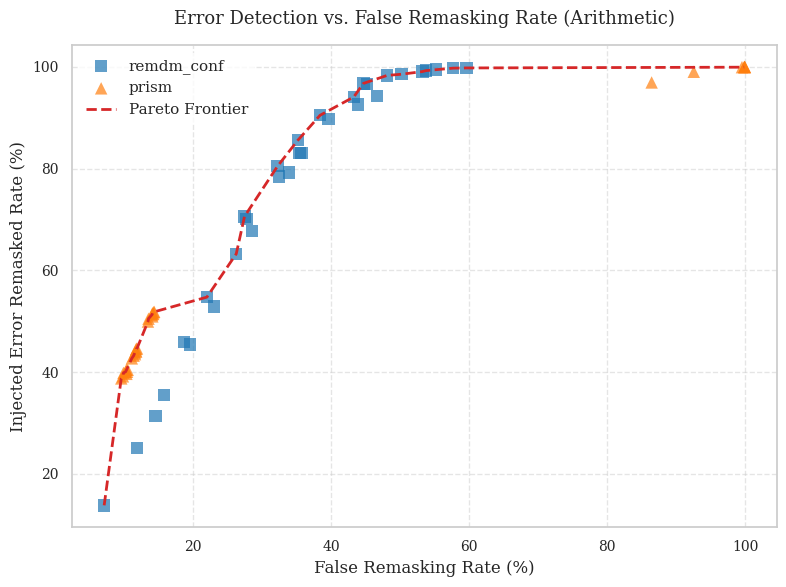

In [13]:
df_copy = merged_df.copy()
# Ensure both remasking quality metrics are numeric
df_copy['false_remasked_cell_pct'] = pd.to_numeric(df_copy['false_remasked_cell_pct'], errors='coerce')
df_copy['injected_error_remasked_pct'] = pd.to_numeric(df_copy['injected_error_remasked_pct'], errors='coerce')

# Drop missing values and sort by false remasking rate
plot_data = df_copy.dropna(subset=['false_remasked_cell_pct', 'injected_error_remasked_pct']).sort_values(by='false_remasked_cell_pct')

plt.figure(figsize=(8, 6))
# Define colors/markers for the remasking methods (dropping low_confidence)
colors = {'remdm_conf': '#1f77b4', 'prism': '#ff7f0e', 'remedi': '#2ca02c'}
markers = {'remdm_conf': 's', 'prism': '^', 'remedi': 'D'}

for method in plot_data['method'].unique():
    method_data = plot_data[plot_data['method'] == method]
    plt.scatter(
        method_data['false_remasked_cell_pct'], 
        method_data['injected_error_remasked_pct'], 
        label=method, 
        color=colors.get(method, '#9467bd'),
        marker=markers.get(method, 'o'),
        alpha=0.7,
        edgecolors='none',
        s=80
    )

# Compute Pareto frontier (Non-dominated points: minimizing X, maximizing Y)
pareto_points = []
for idx, row in plot_data.iterrows():
    x, y = row['false_remasked_cell_pct'], row['injected_error_remasked_pct']
    dominated = False
    for _, other in plot_data.iterrows():
        ox, oy = other['false_remasked_cell_pct'], other['injected_error_remasked_pct']
        if (ox <= x and oy >= y) and (ox < x or oy > y):
            dominated = True
            break
    if not dominated:
        pareto_points.append(row)

if pareto_points:
    pareto_df = pd.DataFrame(pareto_points).sort_values(by='false_remasked_cell_pct')
    plt.plot(
        pareto_df['false_remasked_cell_pct'], 
        pareto_df['injected_error_remasked_pct'], 
        color='#d62728',
        linestyle='--',
        linewidth=2, 
        label='Pareto Frontier'
    )

plt.title("Error Detection vs. False Remasking Rate (Arithmetic)", pad=15)
plt.xlabel("False Remasking Rate (%)")
plt.ylabel("Injected Error Remasked Rate (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

## 5. Heatmaps for PRISM and ReMDM

Let's look at how accuracy changes across different hyperparameter combinations.

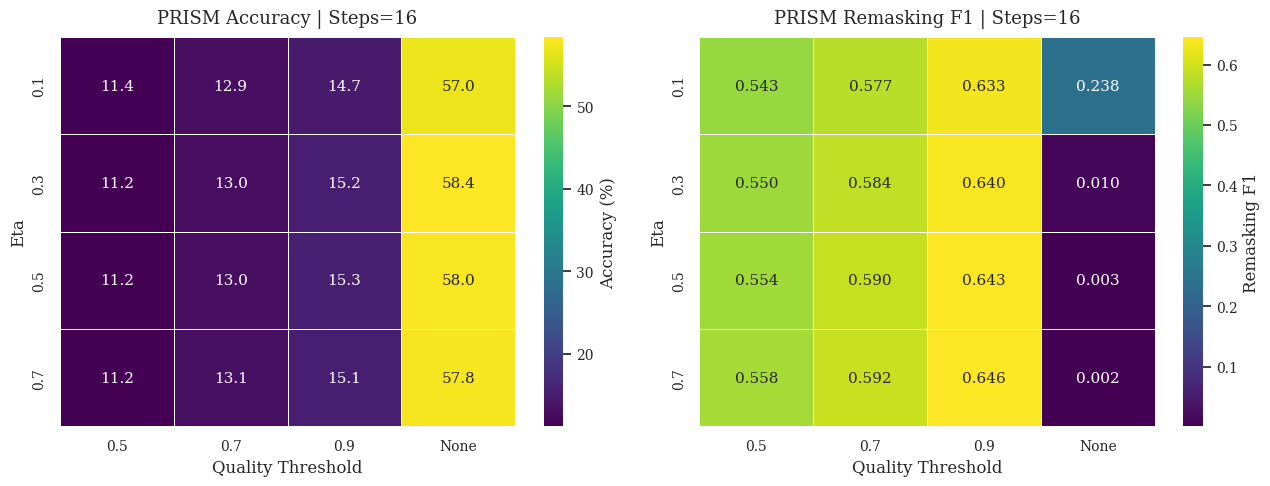

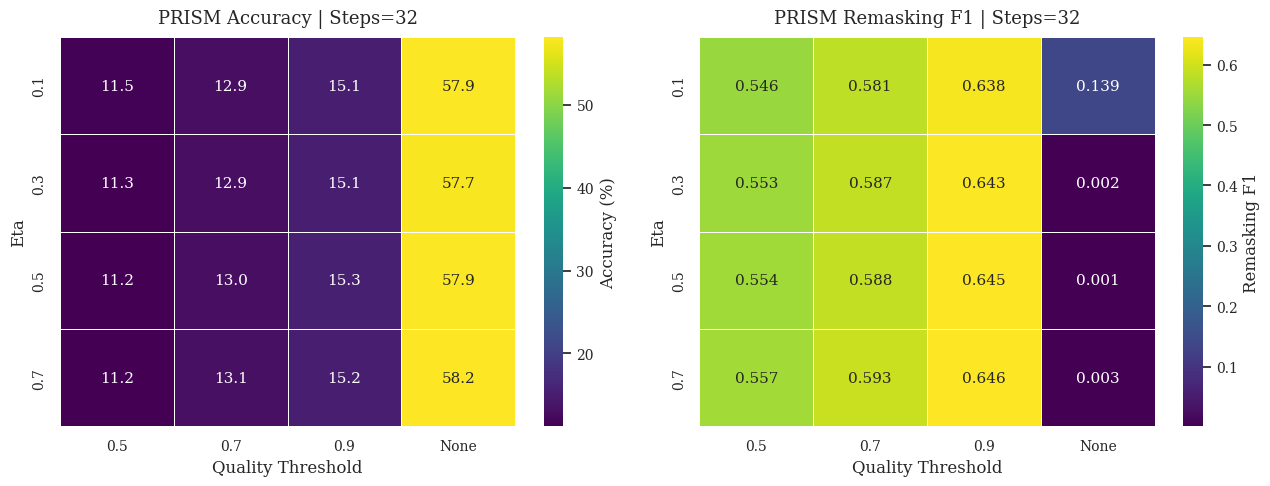

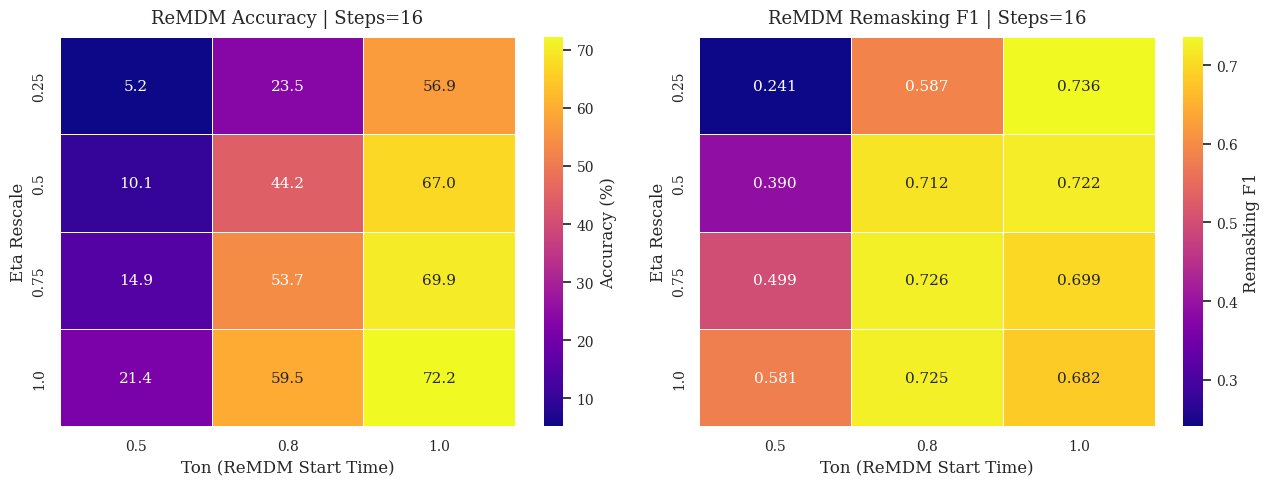

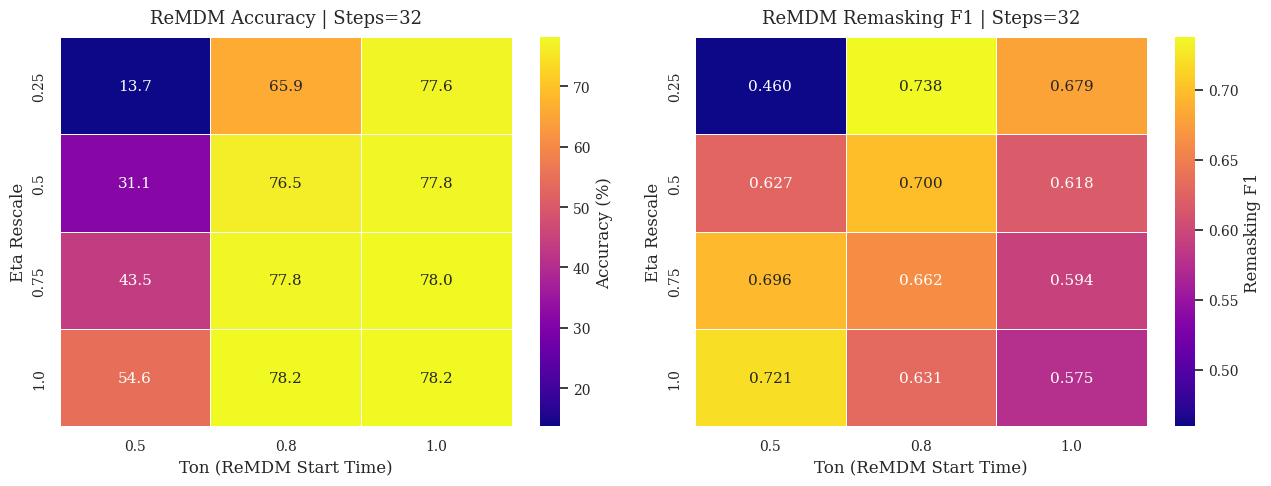

In [15]:
# PRISM Heatmaps (Accuracy & F1 side-by-side)
prism_df = merged_df[merged_df['method'] == 'prism'].copy()
if not prism_df.empty:
    prism_df['prism_quality_threshold'] = prism_df['prism_quality_threshold'].fillna("None").astype(str)
    for steps_val in sorted(prism_df['steps'].unique()):
        subset = prism_df[prism_df['steps'] == steps_val]
        if len(subset['prism_eta'].unique()) > 1:
            pivot_acc = subset.pivot(index='prism_eta', columns='prism_quality_threshold', values='accuracy')
            pivot_f1 = subset.pivot(index='prism_eta', columns='prism_quality_threshold', values='remasking_f1')
            
            fig, axes = plt.subplots(1, 2, figsize=(13, 5))
            
            # Accuracy Heatmap
            sns.heatmap(pivot_acc, ax=axes[0], annot=True, fmt=".1f", cmap="viridis", cbar_kws={'label': 'Accuracy (%)'}, linewidths=0.5)
            axes[0].set_title(f"PRISM Accuracy | Steps={steps_val}", pad=10)
            axes[0].set_xlabel("Quality Threshold")
            axes[0].set_ylabel("Eta")
            
            # F1 Heatmap
            sns.heatmap(pivot_f1, ax=axes[1], annot=True, fmt=".3f", cmap="viridis", cbar_kws={'label': 'Remasking F1'}, linewidths=0.5)
            axes[1].set_title(f"PRISM Remasking F1 | Steps={steps_val}", pad=10)
            axes[1].set_xlabel("Quality Threshold")
            axes[1].set_ylabel("Eta")
            
            plt.tight_layout()
            plt.show()

# ReMDM Heatmaps (Accuracy & F1 side-by-side)
remdm_df = merged_df[merged_df['method'] == 'remdm_conf'].copy()
if not remdm_df.empty:
    for steps_val in sorted(remdm_df['steps'].unique()):
        subset = remdm_df[(remdm_df['steps'] == steps_val) & (remdm_df['remdm_toff'] == 0.0) & (remdm_df['remdm_eta_cap'] == 1.0)]
        if len(subset['remdm_eta_rescale'].unique()) > 1:
            pivot_acc = subset.pivot(index='remdm_eta_rescale', columns='remdm_ton', values='accuracy')
            pivot_f1 = subset.pivot(index='remdm_eta_rescale', columns='remdm_ton', values='remasking_f1')
            
            fig, axes = plt.subplots(1, 2, figsize=(13, 5))
            
            # Accuracy Heatmap
            sns.heatmap(pivot_acc, ax=axes[0], annot=True, fmt=".1f", cmap="plasma", cbar_kws={'label': 'Accuracy (%)'}, linewidths=0.5)
            axes[0].set_title(f"ReMDM Accuracy | Steps={steps_val}", pad=10)
            axes[0].set_xlabel("Ton (ReMDM Start Time)")
            axes[0].set_ylabel("Eta Rescale")
            
            # F1 Heatmap
            sns.heatmap(pivot_f1, ax=axes[1], annot=True, fmt=".3f", cmap="plasma", cbar_kws={'label': 'Remasking F1'}, linewidths=0.5)
            axes[1].set_title(f"ReMDM Remasking F1 | Steps={steps_val}", pad=10)
            axes[1].set_xlabel("Ton (ReMDM Start Time)")
            axes[1].set_ylabel("Eta Rescale")
            
            plt.tight_layout()
            plt.show()
